In [56]:
# ==========================================
# CELL-1. HARDWARE & INITIALIZATION
# ==========================================
import os
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import deepwave
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="deepwave")
print("System Warnings: SUPPRESSED.")

# Initialize Hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"HPC Node Active: {device}\n")

System Warnings: SUPPRESSED.
HPC Node Active: cuda



Model 394 Reconstructed. Grid: 70 x 70


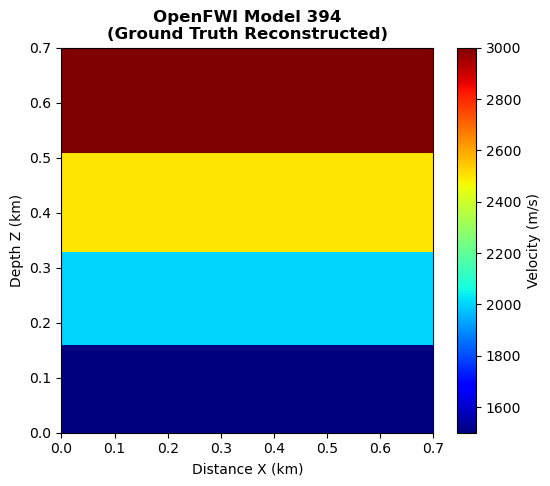

In [57]:
# ==========================================
# CELL-2. RECONSTRUCTING MODEL 394 (4-LAYER)
# ==========================================
# 1. Initialize the 70x70 grid
nx, nz = 70, 70
patch_vp = np.zeros((nx, nz), dtype=np.float32)

# 2. Recreate the 4 exact layers
patch_vp[:, 0:16] = 1500.0  # Top Layer
patch_vp[:, 16:33] = 2000.0 # Second Layer
patch_vp[:, 33:51] = 2500.0 # Third Layer
patch_vp[:, 51:70] = 3000.0 # Bottom Layer

print(f"Model 394 Reconstructed. Grid: {nx} x {nz}")

# 3. Verify visually
plt.figure(figsize=(6, 5))
im = plt.imshow(patch_vp.T, cmap='jet', aspect='auto', extent=[0, 0.7, 0.7, 0])
plt.title("OpenFWI Model 394\n(Ground Truth Reconstructed)", fontweight='bold')
plt.xlabel("Distance X (km)")
plt.ylabel("Depth Z (km)")
plt.colorbar(im, label="Velocity (m/s)")
plt.gca().invert_yaxis()
plt.show()

MVM Prior generated with sigma=2.0


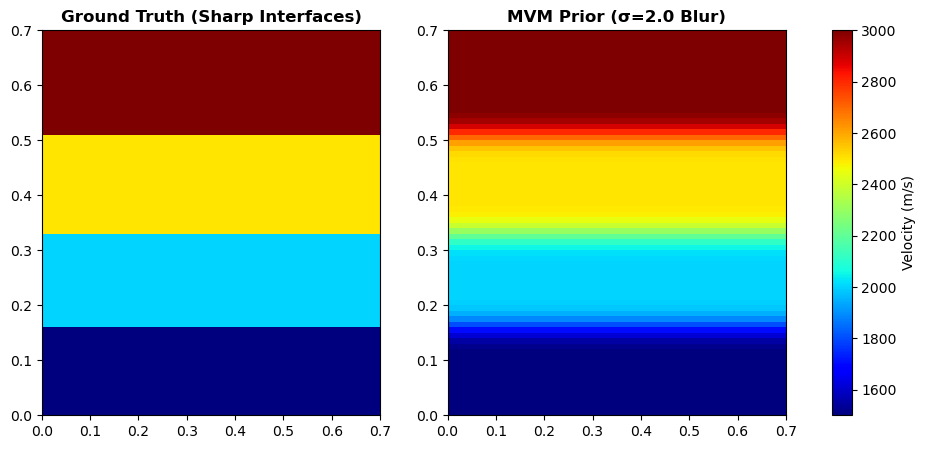

In [58]:
# ==========================================
# CELL-3. PRIOR SYNTHESIS (GAUSSIAN BLUR)
# ==========================================
# Generate the Industrial Prior (Synthetic Tomography via Gaussian Blur)
sigma_blur = 2.0 
mvm_vp = ndimage.gaussian_filter(patch_vp, sigma=sigma_blur)

print(f"MVM Prior generated with sigma={sigma_blur}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(patch_vp.T, cmap='jet', aspect='auto', extent=[0, 0.7, 0.7, 0])
axes[0].set_title("Ground Truth (Sharp Interfaces)", fontweight='bold')
axes[0].invert_yaxis()
im = axes[1].imshow(mvm_vp.T, cmap='jet', aspect='auto', extent=[0, 0.7, 0.7, 0])
axes[1].set_title(f"MVM Prior (σ={sigma_blur} Blur)", fontweight='bold')
axes[1].invert_yaxis()
fig.colorbar(im, ax=axes.ravel().tolist(), label="Velocity (m/s)")
plt.show()

In [59]:
# ==========================================
# CELL-4. PHYSICAL PARAMETERS & ACQUISITION SETUP
# ==========================================
# Physics Parameters
dt, nt, dx = 0.001, 1000, 10.0
num_shots, num_receivers = 21, 70

# Source & Receiver coordinates
source_locations = torch.zeros(num_shots, 1, 2, dtype=torch.long, device=device)
source_locations[:, 0, 0] = torch.linspace(5, nx - 5, num_shots).long()
source_locations[:, 0, 1] = 2 

receiver_locations = torch.zeros(num_shots, num_receivers, 2, dtype=torch.long, device=device)
receiver_locations[:, :, 0] = torch.arange(0, nx).repeat(num_shots, 1)
receiver_locations[:, :, 1] = 2 

# Coordinate Grid
x_grid, z_grid = torch.meshgrid(torch.arange(nx, dtype=torch.float32), 
                                torch.arange(nz, dtype=torch.float32), indexing='ij')
x_flat = (x_grid.flatten().unsqueeze(1) / nx).to(device)
z_flat = (z_grid.flatten().unsqueeze(1) / nz).to(device)

print(f"Acquisition Geometry Initialized: {num_shots} shots, {num_receivers} receivers/shot.")
print(f"Physics Parameters Set: dt={dt}s, nt={nt}, dx={dx}m.")
print("SUCCESS: Acquisition grid and coordinate mapping verified.")

Acquisition Geometry Initialized: 21 shots, 70 receivers/shot.
Physics Parameters Set: dt=0.001s, nt=1000, dx=10.0m.
SUCCESS: Acquisition grid and coordinate mapping verified.


In [60]:
# ==========================================
# CELL-5. ARCHITECTURAL DEFINITION & LOSS FUNCTIONS
# ==========================================
class FourierDeltaPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Multi-scale Fourier features
        self.scales = [1.0, 5.0, 10.0, 20.0]
        self.B = nn.Parameter(torch.randn(2, 64) * 10.0, requires_grad=False)
        self.net = nn.Sequential(
            nn.Linear(128 * len(self.scales), 512), nn.Mish(),
            nn.Linear(512, 512), nn.Mish(),
            nn.Linear(512, 256), nn.Mish(),
            nn.Linear(256, 1)
        )
        
    def forward(self, x, z):
        coords = torch.cat([x, z], dim=1)
        features = []
        for s in self.scales:
            proj = (2.0 * np.pi * s * coords) @ self.B
            features.append(torch.sin(proj))
            features.append(torch.cos(proj))
        
        fourier_features = torch.cat(features, dim=1)
        # Shift the range so it can perturb both up and down significantly
        # 1000 is a standard perturbation magnitude for this velocity range
        return 1000.0 * self.net(fourier_features)

# Essential TV Loss function definition
def balanced_tv_loss(velocity_grid, weight_x=1.0, weight_z=1.0):
    tv_x = torch.sum(torch.abs(velocity_grid[1:, :] - velocity_grid[:-1, :]))
    tv_z = torch.sum(torch.abs(velocity_grid[:, 1:] - velocity_grid[:, :-1]))
    return (weight_x * tv_x) + (weight_z * tv_z)

print("Architecture and TV Loss function successfully registered.")
print("SUCCESS: Ready for Delta-Network Inversion.")

Architecture and TV Loss function successfully registered.
SUCCESS: Ready for Delta-Network Inversion.


In [61]:
# ==========================================
# CELL-6. DATA PREPARATION & INITIALIZATION
# ==========================================
v_true = torch.tensor(patch_vp, dtype=torch.float32, device=device)
v_mvm_tensor = torch.tensor(mvm_vp, dtype=torch.float32, device=device)
v_net_delta = FourierDeltaPINN().to(device)

print(f"Data and Model Initialized: Grid {nx}x{nz}")

Data and Model Initialized: Grid 70x70


In [66]:
# ==========================================
# CELL-7. STAGE 2: DELTA-NETWORK INVERSION (STABILIZED & TRACKED)
# ==========================================
import warnings
import torch.nn.functional as F

# Initialize telemetry tracking
loss_history = []

# 1. Re-initialize the model to wipe the "checkerboard" weights
v_net_delta = FourierDeltaPINN().to(device)
optimizer_delta = torch.optim.Adam(v_net_delta.parameters(), lr=1e-3) 
frequencies = [5.0, 15.0, 25.0]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    
    for freq in frequencies:
        print(f"\n--- Optimizing at {freq} Hz ---")
        source_amplitudes = deepwave.wavelets.ricker(freq, nt, dt, 1.0/freq).reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device)
        
        with torch.no_grad():
            out_true = deepwave.scalar(v_true, grid_spacing=dx, dt=dt, 
                                       source_amplitudes=source_amplitudes, 
                                       source_locations=source_locations, 
                                       receiver_locations=receiver_locations)
            observed = out_true[-1].clone().detach()

        for epoch in range(150):
            optimizer_delta.zero_grad()
            
            # Physics-Informed Delta-Inversion
            delta_v = v_net_delta(x_flat, z_flat).reshape(nx, nz)
            delta_v = torch.clamp(delta_v, -1000.0, 1000.0) 
            v_final = v_mvm_tensor + delta_v
            
            out = deepwave.scalar(v_final, grid_spacing=dx, dt=dt, 
                                  source_amplitudes=source_amplitudes, 
                                  source_locations=source_locations, 
                                  receiver_locations=receiver_locations)
            
            # Use minimal TV weight
            tv_penalty = balanced_tv_loss(v_final, weight_x=1e-8, weight_z=1e-8)
            loss = F.mse_loss(out[-1], observed) + tv_penalty
            
            # Record telemetry for the README dashboard
            loss_history.append(loss.item())
            
            loss.backward()
            
            # Gradient Clipping: Prevent the checkerboard pattern
            nn.utils.clip_grad_norm_(v_net_delta.parameters(), max_norm=0.5)
            
            optimizer_delta.step()
            
            if epoch % 30 == 0:
                print(f"Epoch {epoch} | MSE: {loss.item():.6f}")

print("\nSUCCESS: Optimization stabilized with gradient clipping. Telemetry captured.")


--- Optimizing at 5.0 Hz ---
Epoch 0 | MSE: 0.173260
Epoch 30 | MSE: 0.002999
Epoch 60 | MSE: 0.001850
Epoch 90 | MSE: 0.001519
Epoch 120 | MSE: 0.001418

--- Optimizing at 15.0 Hz ---
Epoch 0 | MSE: 0.007418
Epoch 30 | MSE: 0.003299
Epoch 60 | MSE: 0.002078
Epoch 90 | MSE: 0.001700
Epoch 120 | MSE: 0.002372

--- Optimizing at 25.0 Hz ---
Epoch 0 | MSE: 0.002645
Epoch 30 | MSE: 0.007472
Epoch 60 | MSE: 0.002447
Epoch 90 | MSE: 0.001658
Epoch 120 | MSE: 0.001975

SUCCESS: Optimization stabilized with gradient clipping. Telemetry captured.


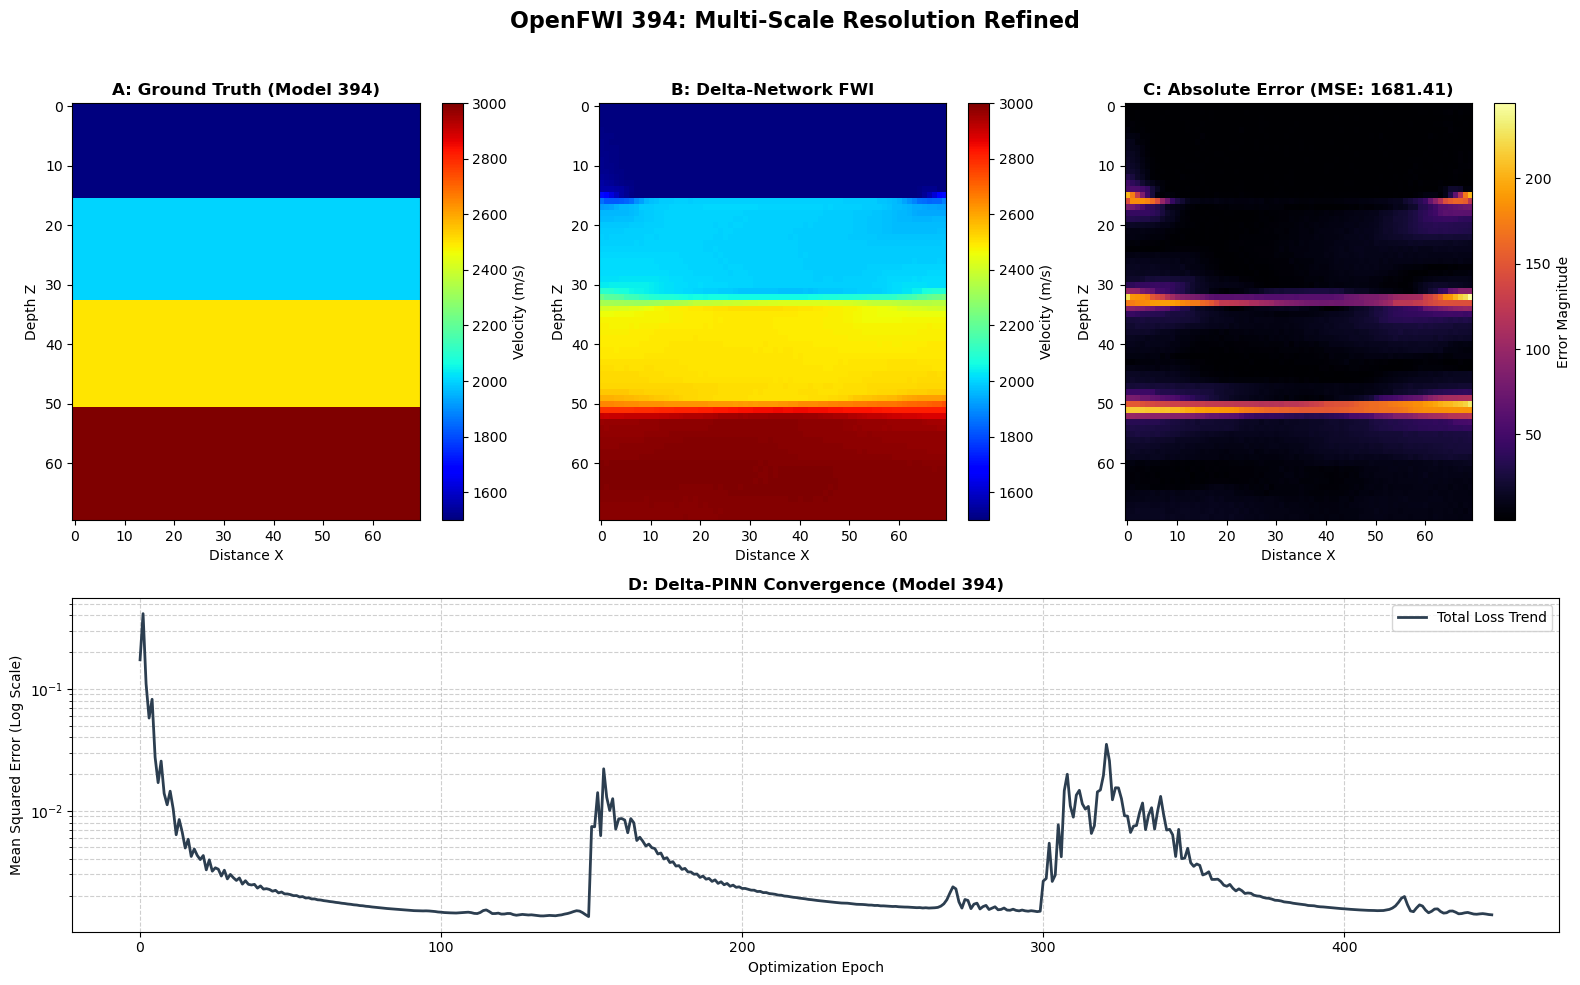

In [67]:
# ==========================================
# CELL-8. CONSOLIDATED OPENFWI 394 DASHBOARD
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Data Preparation
v_net_delta.eval()
with torch.no_grad():
    v_delta_np = v_net_delta(x_flat, z_flat).reshape(nx, nz).cpu().numpy()
    v_final_np = v_mvm_tensor.cpu().numpy() + v_delta_np

absolute_error = np.abs(patch_vp - v_final_np)
mse_val = np.mean(absolute_error**2)

# Create 5-Panel Layout
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 0.8])

# Panel A: Ground Truth
ax1 = fig.add_subplot(gs[0, 0])
im0 = ax1.imshow(patch_vp.T, cmap='jet', aspect='auto', vmin=1500, vmax=3000)
ax1.set_title("A: Ground Truth (Model 394)", fontweight='bold')
ax1.set_xlabel("Distance X"); ax1.set_ylabel("Depth Z")
plt.colorbar(im0, ax=ax1, label="Velocity (m/s)")

# Panel B: Delta-Network FWI
ax2 = fig.add_subplot(gs[0, 1])
im1 = ax2.imshow(v_final_np.T, cmap='jet', aspect='auto', vmin=1500, vmax=3000)
ax2.set_title("B: Delta-Network FWI", fontweight='bold')
ax2.set_xlabel("Distance X"); ax2.set_ylabel("Depth Z")
plt.colorbar(im1, ax=ax2, label="Velocity (m/s)")

# Panel C: Absolute Error
ax3 = fig.add_subplot(gs[0, 2])
im2 = ax3.imshow(absolute_error.T, cmap='inferno', aspect='auto')
ax3.set_title(f"C: Absolute Error (MSE: {mse_val:.2f})", fontweight='bold')
ax3.set_xlabel("Distance X"); ax3.set_ylabel("Depth Z")
plt.colorbar(im2, ax=ax3, label="Error Magnitude")

# Panel D: Convergence Chart
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(loss_history, color='#2c3e50', label='Total Loss Trend', linewidth=2)
ax4.set_yscale('log')
ax4.set_title("D: Delta-PINN Convergence (Model 394)", fontweight='bold')
ax4.set_xlabel("Optimization Epoch")
ax4.set_ylabel("Mean Squared Error (Log Scale)")
ax4.grid(True, which='both', linestyle='--', alpha=0.6)
ax4.legend()

plt.suptitle("OpenFWI 394: Multi-Scale Resolution Refined", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [68]:
# Diagnostics: Check if the network is "dead"
with torch.no_grad():
    delta_vals = v_net_delta(x_flat, z_flat).cpu().numpy()
    print(f"Network output range: {delta_vals.min():.2f} to {delta_vals.max():.2f}")
    
# If the range is very small (e.g., < 0.01), your learning rate or activation scaling is too low.

Network output range: -207.63 to 196.05


In [69]:
# Run this in the last cell of your notebooks to export the final figure
# Adjust 'fig' to match the variable name of your final figure
fig.savefig('openfwi_m394_results.png', dpi=300, bbox_inches='tight')  # For 4-layer experiment
print("Visualizations exported successfully.")

Visualizations exported successfully.
